In [165]:
# !pip install......

# !pip install pandas numpy matplotlib
# !pip install japanize-matplotlib 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib # 日本語フォント対応
import seaborn as sns

In [2]:
# df.to_csv('/Users/balalala/Documents/GitHub/Consumption_Data/Data_time_series/en_setai_over2_monthly.csv', index=False)
df = pd.read_csv('/Users/balalala/Documents/GitHub/Consumption_Data/Data_time_series/en_setai_over2_monthly.csv')

In [4]:
df.head(17)

,Category level 1,Category level 2,Category level 3,Item,2000-01,2000-02,2000-03,2000-04,2000-05,2000-06,...,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11
0,-,-,-,Household number distribution (sampling rate a...,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,...,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
1,-,-,-,Total number of households,7887.00,7942.00,7934.00,7922.00,7928.00,7917.00,...,7273.00,7263.00,7302.00,7325.00,7285.00,7260.00,7256.00,7270.00,7232.00,7239.00
2,-,-,-,Household members (people),3.32,3.32,3.32,3.32,3.31,3.31,...,2.88,2.88,2.88,2.87,2.87,2.87,2.87,2.87,2.87,2.87
3,-,-,-,Number of people under 18 years old (persons),0.74,0.75,0.75,0.75,0.75,0.74,...,0.52,0.52,0.53,0.52,0.52,0.52,0.52,0.52,0.51,0.51
4,-,-,-,Number of people aged 65 and over (people),0.52,0.53,0.53,0.52,0.52,0.53,...,0.84,0.85,0.84,0.84,0.85,0.86,0.87,0.86,0.87,0.88
5,-,-,-,Number of unemployed people (people),0.41,0.41,0.41,0.41,0.41,0.42,...,0.66,0.66,0.66,0.66,0.67,0.66,0.67,0.67,0.68,0.68
6,-,-,-,Employed personnel (persons),1.51,1.51,1.51,1.52,1.53,1.53,...,1.33,1.33,1.32,1.33,1.33,1.35,1.35,1.35,1.35,1.35
7,-,-,-,Age of household head (years),52.40,52.60,52.70,52.60,52.70,52.60,...,60.40,60.60,60.50,60.50,60.60,60.80,61.00,60.70,61.00,61.00
8,-,-,-,Home ownership rate (%),76.00,76.30,76.20,75.80,76.10,76.00,...,86.80,87.00,86.90,86.90,87.00,87.00,87.20,87.60,87.90,88.00
9,-,-,-,Percentage of households paying rent/ground re...,22.10,22.00,22.60,22.20,22.60,22.90,...,12.20,12.00,11.90,11.80,12.30,12.10,11.80,11.50,10.80,10.70


In [5]:
# Filter for rows where Medium (中分類) and Minor (小分類) are '-'
# This isolates the top-level "Major" rows

major_rows = df[ (df['Category level 1'] != '-') & (df['Category level 2'] == '-') & (df['Category level 3'] == '-') ]

major_dict = dict(zip(major_rows['Category level 1'], major_rows['Item']))
print(major_dict['1']) # Output: 食料

hierarchy = {}

# Iterate through every row
for index, row in df.iterrows():
    major_id = row['Category level 1']
    med_id = row['Category level 2']
    min_id = row['Category level 3']
    name = row['Item']

    # Skip header/garbage rows if any
    if major_id == '-': continue 

    # 1. Initialize Major Level
    # We use the ID as the key, but store the Name inside
    if major_id not in hierarchy:
        # Look up the major name from our simple dict
        major_name = major_dict.get(major_id, "他")
        hierarchy[major_id] = {'name': major_name, 'med': {}}

    # 2. Add Medium Level (if this row represents a Medium category or deeper)
    if med_id != '-':
        if med_id not in hierarchy[major_id]['med']:
             # Use the name if this is the defining row, otherwise generic placeholder until found
            hierarchy[major_id]['med'][med_id] = {'name': name, 'small': {}}
        
        # Update name if this is exactly the Medium definition row
        if min_id == '-':
            hierarchy[major_id]['med'][med_id]['name'] = name

    # 3. Add Minor Level (if this row represents a Minor category)
    if min_id != '-':
        # Add the minor category to the medium's children
        hierarchy[major_id]['med'][med_id]['small'][min_id] = name
# Usage:
# hierarchy[1]['children'][1]['name']  -> Access the name of Medium Category 1 inside Major 1
# Initialize the flat dictionary
# Key = Item Name (e.g., 'パン'), Value = Formatted String (e.g., '食料ーパン')

name_to_path_map = {}

# Iterate through the hierarchy
for major_id, major_data in hierarchy.items():
    major_name = major_data['name']
    
    # 1. Add the Major category itself (Optional, if needed)
    # name_to_path_map[major_name] = major_name
    
    # Check if 'med' exists
    if 'med' in major_data:
        for med_id, med_data in major_data['med'].items():
            med_name = med_data['name']
            
            # 2. Add Medium Category: Input '穀類' -> Output '食料ー穀類'
            name_to_path_map[med_name] = f"{major_name}ー{med_name}"
            
            # Check if 'small' exists
            if 'small' in med_data:
                for small_id, small_name in med_data['small'].items():
                    # 3. Add Small Category: Input 'パン' -> Output '食料ーパン'
                    # Note: Using strict user format "Major-Small". 
                    # If you wanted full path "Major-Med-Small", use: f"{major_name}ー{med_name}ー{small_name}"
                    name_to_path_map[small_name] = f"{major_name}ー{med_name}ー{small_name}"

# Check the result
print(name_to_path_map['bread']) 
# Output: '食料ーパン'

def get_category_path(item_name):
    return name_to_path_map.get(item_name, item_name) # Returns "他" if not found

print(get_category_path('bread'))

food
foodーgrainsーbread
foodーgrainsーbread


In [ ]:
# --- Step 1: Flatten your hierarchy dictionary ---
# This converts: {'1': {'name': 'food', 'med': {'1': {'name': 'grains', 'small': {'1': 'rice'...
# To: {'rice': 'food', 'bread': 'food', ...}

category_map = {}

for l1_id, l1_info in hierarchy.items():
    l1_name = l1_info['name']
    for l2_id, l2_info in l1_info['med'].items():
        # Option A: Map to Level 1 (Food vs Transport)
        # Option B: Map to Level 2 (Grains vs Meat)
        # Let's map to Level 1 for a high-level systemic view
        for l3_id, l3_name in l2_info['small'].items():
            category_map[l3_name] = l1_name

# Convert to a Series for easy grouping
category_series = pd.Series(category_map)
category_series

In [6]:
total_cums = pd.Series(df.iloc[10, 4:].astype(float)).values
# 3. Create the new "Share" DataFrame
df_share = df.copy()

# Convert all date columns to numeric first (just in case)
df_share.iloc[:, 4:] = df_share.iloc[:, 4:].astype(float)
df_share.iloc[11:, 4:] = (
    df_share.iloc[11:, 4:]
    .div(total_cums, axis=1)
    .mul(100)
    .round(4)
)
df_share.head(17)

df_share.to_csv('/Users/balalala/Documents/GitHub/Consumption_Data/Data_time_series/en_share_over2_monthly.csv', index=False)

In [ ]:
# df_share = pd.read_csv('/Users/balalala/Documents/GitHub/Consumption_Data/Data_time_series/en_share_over2_monthly.csv')

In [113]:
# Dataframe for 3 levels of category hierarchy

c1 = df_share[(df_share['Category level 1']!='-') & (df_share['Category level 2']=='-') & (df_share['Category level 3']=='-')]

c2 = df_share[(df_share['Category level 1']!='-') & (df_share['Category level 2']!='-') & (df_share['Category level 3']=='-')]

c3 = df_share[(df_share['Category level 1']!='-') & (df_share['Category level 2']!='-') & (df_share['Category level 3']!='-')]

# Comprehensive Guide to Random Matrix Theory (RMT) in Big Data Analysis

This document summarizes the core methodologies of applying Random Matrix Theory (RMT) to high-dimensional time-series data (e.g., human flow, traffic data, financial networks).

## 1. Foundation: Covariance and Correlation

### 1.1 The Intuition of Covariance
Covariance measures whether two variables (e.g., foot traffic at Station A and Station B) move in tandem. 
The fundamental formula, $\text{Cov}(X,Y) = \frac{1}{N} \sum (X - \mu_X)(Y - \mu_Y)$, works by pairing deviations from the mean. 
* **Positive Product (+ × + or - × -):** Both variables are moving in the same direction relative to their means (synergy).
* **Negative Product (+ × -):** Variables are moving in opposite directions (divergence).

### 1.2 Matrix Calculation via Standardization (Z-score)
In big data, we avoid slow element-wise calculations. By standardizing the data first, covariance simplifies to pure matrix multiplication.
For a data matrix $X$, we standardize it into $Z$ using Z-scores: $z_{i,t} = \frac{x_{i,t} - \mu_i}{\sigma_i}$.
The correlation matrix $C$ is computed efficiently via matrix multiplication:
$$C = \frac{1}{T} Z Z^T$$
Where $T$ is the number of time periods. The $(i, j)$ element of $C$ represents the Pearson correlation coefficient between variable $i$ and $j$.



## 2. Temporal Dynamics: The Sliding Window

Real-world systems are non-stationary. RMT captures these dynamic shifts using a **Sliding Window** of size $W$.
* **Mechanism:** Data is subset into $[t, t+W]$, calculating a local correlation matrix $C(t)$. The window then rolls forward by step $S$.
* **Regime Shift Detection:** By observing the evolution of matrices over time, we can detect system-wide state transitions (e.g., the onset of a traffic gridlock). Note that $W$ must be larger than the number of variables $N$ ($Q = W/N > 1$) to ensure statistical validity.



## 3. The RMT Filter: Separating Signal from Noise

When $N$ is large, empirical correlation matrices contain significant random noise. RMT provides the theoretical framework to filter this.

### 3.1 Marchenko-Pastur (MP) Law
If the system contains only pure random noise, the eigenvalues of its correlation matrix will follow the MP distribution, strictly bounded by:
$$\lambda_{max/min} = 1 + \frac{N}{T} \pm 2\sqrt{\frac{N}{T}}$$

### 3.2 Eigendecomposition and Filtering
We decompose the empirical matrix $C$: $C\mathbf{v} = \lambda\mathbf{v}$.
* **Noise (Random Fluctuations):** Eigenvalues within $[\lambda_{min}, \lambda_{max}]$ are discarded as white noise.
* **Signal (Core Drivers):** Deviating eigenvalues where $\lambda > \lambda_{max}$ represent genuine collective behaviors in the system.



### 3.3 Interpretation of Eigenvectors
For a significant eigenvalue $\lambda_i$, its corresponding **Eigenvector $\mathbf{v}_i$** reveals the "Spatial Pattern" of the signal. The elements of the vector assign weights to each variable, showing which geographical locations or nodes are acting collectively to drive the system.

---

# 時系列データ解析におけるランダム行列理論 (RMT) の包括的ガイド

このドキュメントは、高次元時系列データ（例：人流データ、交通データ、金融ネットワーク）に対するランダム行列理論（RMT）の適用手法について要約したものです。

## 1. 基礎概念：共分散と相関

### 1.1 共分散の直感的理解
共分散は、2つの変数（例：駅Aと駅Bの歩行者数）が連動して動くかどうかを測定します。
基本公式 $\text{Cov}(X,Y) = \frac{1}{N} \sum (X - \mu_X)(Y - \mu_Y)$ は、平均からの偏差をペアリングすることによって機能します。
* **正の積 (+ × + または - × -):** 両変数が平均に対して同じ方向に動いている（協調）。
* **負の積 (+ × -):** 変数が逆方向に動いている（背反）。

### 1.2 標準化 (Z-score) による行列表現
ビッグデータ分析では、計算コストを減らすために行列演算を使用します。データを事前に標準化することで、共分散は単純な行列の積になります。
データ行列 $X$ をZ-scoreを用いて $Z$ に標準化します：$z_{i,t} = \frac{x_{i,t} - \mu_i}{\sigma_i}$。
相関行列 $C$ は以下の行列の積で効率的に計算されます：
$$C = \frac{1}{T} Z Z^T$$
ここで、$T$ は時間長（サンプル数）です。行列 $C$ の $(i, j)$ 成分は、変数 $i$ と $j$ のピアソン相関係数を表します。

## 2. 時間的ダイナミクス：スライディングウィンドウ

現実世界のシステムは非定常（Non-stationary）です。RMTでは、サイズ $W$ の**スライディングウィンドウ（移動窓）**を用いて動的な変化を捉えます。
* **メカニズム:** データを時間区間 $[t, t+W]$ で切り出し、局所的な相関行列 $C(t)$ を計算します。その後、ウィンドウをステップ $S$ ずつ前方にスライドさせます。
* **レジームシフト（状態遷移）の検知:** 相関行列の時間発展を観察することで、システム全体の状態遷移（例：交通渋滞の発生）を検知できます。なお、統計的妥当性を確保するためには、$W$ は変数（ノード）の数 $N$ より大きくなければなりません（$Q = W/N > 1$）。

## 3. RMTフィルター：ノイズとシグナルの分離

変数 $N$ が大きい場合、実証的な相関行列には大量のランダムノイズが含まれます。RMTは、これをフィルタリングするための理論的枠組みを提供します。

### 3.1 マルチェンコ・パストゥール (MP) 定理
システムが純粋なランダムノイズのみで構成されている場合、その相関行列の固有値はMP分布に従い、以下の理論的限界内に収まります：
$$\lambda_{max/min} = 1 + \frac{N}{T} \pm 2\sqrt{\frac{N}{T}}$$

### 3.2 固有値分解とフィルタリング
実証行列 $C$ を固有値分解します：$C\mathbf{v} = \lambda\mathbf{v}$。
* **ノイズ（ランダムな揺らぎ）:** $[\lambda_{min}, \lambda_{max}]$ の範囲内にある固有値は、ホワイトノイズとして破棄します。
* **シグナル（コアな駆動力）:** $\lambda > \lambda_{max}$ となる逸脱した固有値は、システム内の真の集団的振る舞い（シグナル）を表します。

### 3.3 固有ベクトルの解釈
有意な固有値 $\lambda_i$ に対応する**固有ベクトル $\mathbf{v}_i$** は、シグナルの「空間的パターン（Spatial Pattern）」を明らかにします。ベクトルの各成分は各変数の重みを表し、どの地理的場所やノードがシステムを駆動するために集団で作用しているかを示します。

### Data Preprocessing & Signal Extraction for RMT

This section prepares the raw consumption percentage data for Random Matrix Theory (RMT) analysis. Since RMT's foundational Marchenko-Pastur Law requires the input matrix elements to be independent and identically distributed (i.i.d.) random variables with mean $0$ and variance $1$ ($\mu = 0, \sigma^2 = 1$), the data is passed through a three-step pipeline:

1. **Data Restructuring (`prep_data_for_stl`):** - Transposes the DataFrame so that time is on the index (rows) and items are columns.
   - Converts the index to a proper chronological `datetime` format and casts values to `float64` for computational stability.

2. **Stationarity via STL Decomposition (`get_residuals`):**
   - Applies Seasonal-Trend Decomposition using LOESS (STL) to isolate the residual component.
   - **Rationale:** Consumption percentages naturally contain seasonal cycles and long-term trends. By extracting the **residuals**, we isolate the stationary "shocks" (unexpected changes in consumption). The `robust=True` parameter ensures that extreme outliers (e.g., COVID-19 anomalies) do not skew the trend/seasonal fit.

3. **Z-Score Normalization:**
   - Standardizes the extracted residuals across each item to have a mean of $0$ and a standard deviation of $1$.
   - **Rationale:** Eliminates heteroskedasticity. Without standardization, high-variance consumption items would disproportionately dominate the covariance matrix and skew the empirical eigenvalue distribution.

**Output:** `df_res_norm` is a strictly stationary, standardized DataFrame of consumption shocks, ready for correlation matrix computation.

In [125]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from scipy.stats import zscore

def prep_data_for_stl(raw_df: pd.DataFrame, meta_col_count: int = 3) -> pd.DataFrame:
    """
    Cleans raw DataFrame and transposes it into a Time x Items format.
    """
    # 1. Extract and Transpose
    df_ts = raw_df.set_index('Item').iloc[:, meta_col_count:]
    df_t = df_ts.T

    # 2. Index Formatting
    df_t.index = pd.to_datetime(df_t.index)
    df_t = df_t.sort_index()

    # 3. Type Casting & Handle Missing Data (STL requires no NaNs)
    df_t = df_t.astype(np.float64)
    # df_t = df_t.ffill().bfill() # Forward/backward fill any missing percentages
    
    return df_t

def get_residuals(series: pd.Series, period: int = 12) -> pd.Series:
    """
    Extracts the residual component from a time series using STL.
    """
    # robust=True handles outliers (like COVID-19 anomalies) better
    res = STL(series, period=period, robust=True).fit()
    return res.resid


# Comprehensive Guide to Random Matrix Theory (RMT) in Big Data Analysis

This document summarizes the core methodologies of applying Random Matrix Theory (RMT) to high-dimensional time-series data (e.g., human flow, traffic data, financial networks).

## 1. Foundation: Covariance and Correlation

### 1.1 The Intuition of Covariance
Covariance measures whether two variables (e.g., foot traffic at Station A and Station B) move in tandem. 
The fundamental formula, $\text{Cov}(X,Y) = \frac{1}{N} \sum (X - \mu_X)(Y - \mu_Y)$, works by pairing deviations from the mean. 
* **Positive Product (+ × + or - × -):** Both variables are moving in the same direction relative to their means (synergy).
* **Negative Product (+ × -):** Variables are moving in opposite directions (divergence).

### 1.2 Matrix Calculation via Standardization (Z-score)
In big data, we avoid slow element-wise calculations. By standardizing the data first, covariance simplifies to pure matrix multiplication.
For a data matrix $X$, we standardize it into $Z$ using Z-scores: $z_{i,t} = \frac{x_{i,t} - \mu_i}{\sigma_i}$.
The correlation matrix $C$ is computed efficiently via matrix multiplication:
$$C = \frac{1}{T} Z Z^T$$
Where $T$ is the number of time periods. The $(i, j)$ element of $C$ represents the Pearson correlation coefficient between variable $i$ and $j$.



## 2. Temporal Dynamics: The Sliding Window

Real-world systems are non-stationary. RMT captures these dynamic shifts using a **Sliding Window** of size $W$.
* **Mechanism:** Data is subset into $[t, t+W]$, calculating a local correlation matrix $C(t)$. The window then rolls forward by step $S$.
* **Regime Shift Detection:** By observing the evolution of matrices over time, we can detect system-wide state transitions (e.g., the onset of a traffic gridlock). Note that $W$ must be larger than the number of variables $N$ ($Q = W/N > 1$) to ensure statistical validity.



## 3. The RMT Filter: Separating Signal from Noise

When $N$ is large, empirical correlation matrices contain significant random noise. RMT provides the theoretical framework to filter this.

### 3.1 Marchenko-Pastur (MP) Law
If the system contains only pure random noise, the eigenvalues of its correlation matrix will follow the MP distribution, strictly bounded by:
$$\lambda_{max/min} = 1 + \frac{N}{T} \pm 2\sqrt{\frac{N}{T}}$$

### 3.2 Eigendecomposition and Filtering
We decompose the empirical matrix $C$: $C\mathbf{v} = \lambda\mathbf{v}$.
* **Noise (Random Fluctuations):** Eigenvalues within $[\lambda_{min}, \lambda_{max}]$ are discarded as white noise.
* **Signal (Core Drivers):** Deviating eigenvalues where $\lambda > \lambda_{max}$ represent genuine collective behaviors in the system.



### 3.3 Interpretation of Eigenvectors
For a significant eigenvalue $\lambda_i$, its corresponding **Eigenvector $\mathbf{v}_i$** reveals the "Spatial Pattern" of the signal. The elements of the vector assign weights to each variable, showing which geographical locations or nodes are acting collectively to drive the system.

---

# 時系列データ解析におけるランダム行列理論 (RMT) の包括的ガイド

このドキュメントは、高次元時系列データ（例：人流データ、交通データ、金融ネットワーク）に対するランダム行列理論（RMT）の適用手法について要約したものです。

## 1. 基礎概念：共分散と相関

### 1.1 共分散の直感的理解
共分散は、2つの変数（例：駅Aと駅Bの歩行者数）が連動して動くかどうかを測定します。
基本公式 $\text{Cov}(X,Y) = \frac{1}{N} \sum (X - \mu_X)(Y - \mu_Y)$ は、平均からの偏差をペアリングすることによって機能します。
* **正の積 (+ × + または - × -):** 両変数が平均に対して同じ方向に動いている（協調）。
* **負の積 (+ × -):** 変数が逆方向に動いている（背反）。

### 1.2 標準化 (Z-score) による行列表現
ビッグデータ分析では、計算コストを減らすために行列演算を使用します。データを事前に標準化することで、共分散は単純な行列の積になります。
データ行列 $X$ をZ-scoreを用いて $Z$ に標準化します：$z_{i,t} = \frac{x_{i,t} - \mu_i}{\sigma_i}$。
相関行列 $C$ は以下の行列の積で効率的に計算されます：
$$C = \frac{1}{T} Z Z^T$$
ここで、$T$ は時間長（サンプル数）です。行列 $C$ の $(i, j)$ 成分は、変数 $i$ と $j$ のピアソン相関係数を表します。

## 2. 時間的ダイナミクス：スライディングウィンドウ

現実世界のシステムは非定常（Non-stationary）です。RMTでは、サイズ $W$ の**スライディングウィンドウ（移動窓）**を用いて動的な変化を捉えます。
* **メカニズム:** データを時間区間 $[t, t+W]$ で切り出し、局所的な相関行列 $C(t)$ を計算します。その後、ウィンドウをステップ $S$ ずつ前方にスライドさせます。
* **レジームシフト（状態遷移）の検知:** 相関行列の時間発展を観察することで、システム全体の状態遷移（例：交通渋滞の発生）を検知できます。なお、統計的妥当性を確保するためには、$W$ は変数（ノード）の数 $N$ より大きくなければなりません（$Q = W/N > 1$）。

## 3. RMTフィルター：ノイズとシグナルの分離

変数 $N$ が大きい場合、実証的な相関行列には大量のランダムノイズが含まれます。RMTは、これをフィルタリングするための理論的枠組みを提供します。

### 3.1 マルチェンコ・パストゥール (MP) 定理
システムが純粋なランダムノイズのみで構成されている場合、その相関行列の固有値はMP分布に従い、以下の理論的限界内に収まります：
$$\lambda_{max/min} = 1 + \frac{N}{T} \pm 2\sqrt{\frac{N}{T}}$$

### 3.2 固有値分解とフィルタリング
実証行列 $C$ を固有値分解します：$C\mathbf{v} = \lambda\mathbf{v}$。
* **ノイズ（ランダムな揺らぎ）:** $[\lambda_{min}, \lambda_{max}]$ の範囲内にある固有値は、ホワイトノイズとして破棄します。
* **シグナル（コアな駆動力）:** $\lambda > \lambda_{max}$ となる逸脱した固有値は、システム内の真の集団的振る舞い（シグナル）を表します。

### 3.3 固有ベクトルの解釈
有意な固有値 $\lambda_i$ に対応する**固有ベクトル $\mathbf{v}_i$** は、シグナルの「空間的パターン（Spatial Pattern）」を明らかにします。ベクトルの各成分は各変数の重みを表し、どの地理的場所やノードがシステムを駆動するために集団で作用しているかを示します。

|                     |     grains |     seafood |      meat |    milk eggs |   Vegetables/seaweed |      fruit |   Oils and seasonings |   Confectionery |   cooked food |   beverage |   Alcoholic beverages |   Eating out |   rent and ground rent |   Equipment repair/maintenance |   electricity bill |   gas bill |   other light heat |   Water and sewage charges |   household durable goods |   Interior equipment/decoration items |   Bedding |   Housework miscellaneous goods |   Housework consumables |   housekeeping services |   Japanese clothes |     clothes |   Shirts/Sweaters |   Underwear |   Fabric/thread |   other clothing |   footwear |   Clothing related services |   pharmaceuticals |   Intakes for maintaining health |   Health and medical supplies/equipment |   health and medical services |    traffic |   Car-related expenses |   communication |   Tuition fees etc. |   Textbooks/study reference materials |   supplementary education |   Educational and recreational durable goods

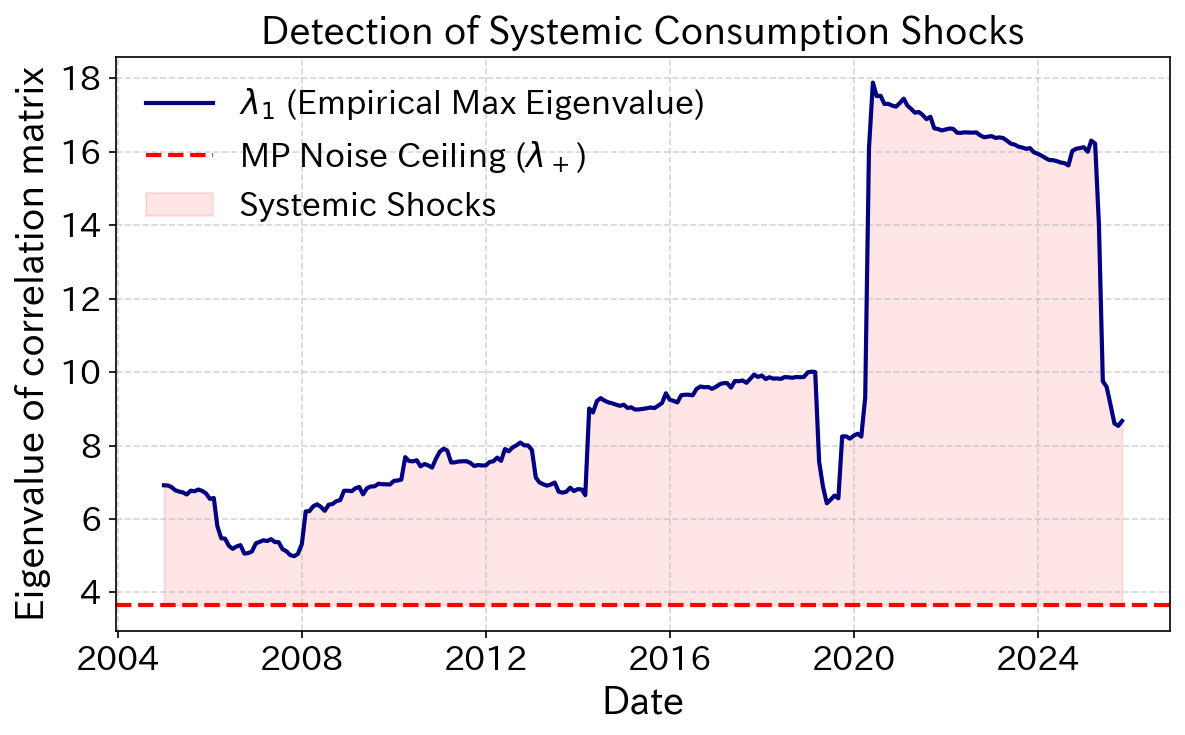

In [191]:
# --- Execution Pipeline ---

# STEP 1: Clean and Transpose raw consumption data
df_clean = prep_data_for_stl(c2, meta_col_count=3)

# STEP 2: Apply STL to get the Residuals (Deviations from trend/seasonality)
df_residuals = df_clean.apply(get_residuals, period=12)

# STEP 3: Apply Z-Score Normalization
df_res_norm = df_residuals.apply(zscore)

# STEP 4: Output as Markdown
# Using .to_markdown() converts the dataframe head into a formatted markdown table
markdown_output = df_res_norm.head().to_markdown()
print(markdown_output)
print(df_res_norm.shape)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Optional: just to make plots look nicer

# --- 1. CRITICAL FIX: Window size must be > N (144) ---
window_size = 60  # Results in Q = 150/144 = 1.04
N = df_res_norm.shape[1]  # No.of items
Q = window_size / N   # The aspect ratio (T/N)

# MP Theory Noise Ceiling (Calculated once outside the loop)
lambda_plus = (1 + np.sqrt(1/Q))**2  

# --- 2. Rolling Window Loop (Correct as written) ---
lambda_max_series = []
dates = []

for i in range(len(df_res_norm) - window_size):
    # Slice current window
    window = df_res_norm.iloc[i : i + window_size]
    
    # Calculate correlation matrix and extract eigenvalues
    # Note: .eigvalsh is computationally faster for symmetric matrices
    corr_mat = window.corr()
    evals = np.linalg.eigvalsh(corr_mat)
    
    # Append the largest eigenvalue (Systemic Market Factor)
    lambda_max_series.append(max(evals))
    # Tag the date to the END of the rolling window
    dates.append(df_res_norm.index[i + window_size])

# --- 3. Visualization ---
plt.figure(figsize=(8, 5), dpi=150)
ax = plt.subplot(1,1,1)

# Plot empirical max eigenvalue
ax.plot(dates, lambda_max_series, color='navy', linewidth=2, label=r'$\lambda_1$ (Empirical Max Eigenvalue)')

# Plot theoretical noise ceiling
ax.axhline(y=lambda_plus, color='red', linestyle='--', linewidth=2, label=r'MP Noise Ceiling ($\lambda_+$)')

# Shaded area for visual impact (highlighting systemic shocks)
ax.fill_between(dates, lambda_max_series, lambda_plus, 
                where=(np.array(lambda_max_series) > lambda_plus), 
                color='red', alpha=0.1, label='Systemic Shocks')

ax.set_title('Detection of Systemic Consumption Shocks', fontsize=18, fontweight='bold')
ax.set_ylabel('Eigenvalue of correlation matrix', fontsize=18)
ax.set_xlabel('Date', fontsize=18)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=16, loc='best', frameon=False)

ax.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()

|                     |         food |   residence |   Utilities/Water |   Furniture/household supplies |   clothing and footwear |   health care |   Transportation/Communication |   education |   educational entertainment |   Other consumption expenditure |
|:--------------------|-------------:|------------:|------------------:|-------------------------------:|------------------------:|--------------:|-------------------------------:|------------:|----------------------------:|--------------------------------:|
| 2000-01-01 00:00:00 |  0.242659    |  0.146333   |        -0.303383  |                     -0.0391812 |                0.760769 |      0.524308 |                     -0.241736  |   0.20041   |                 -0.00815925 |                      -0.0150675 |
| 2000-02-01 00:00:00 | -0.000365243 | -0.0705798  |         0.0480249 |                     -0.334306  |                0.15343  |      0.630427 |                      0.0373436 |  -0.294522  |                  0.370517   

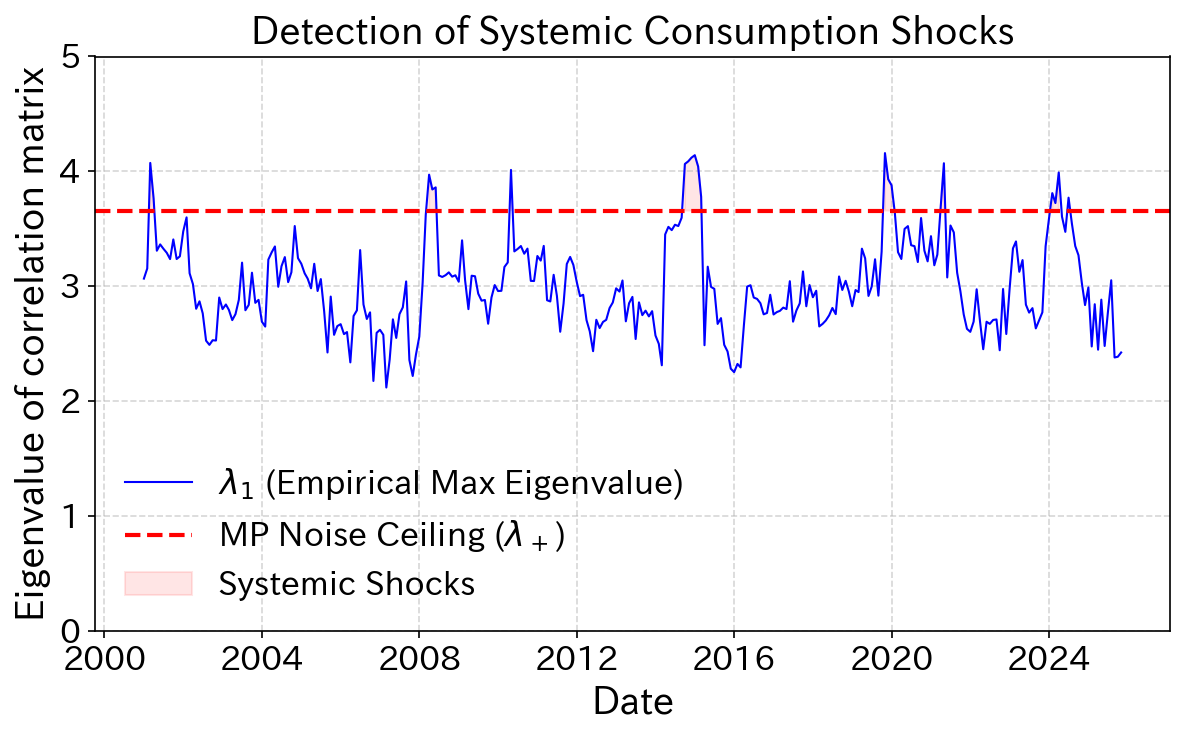

In [143]:
# --- Execution Pipeline ---

# STEP 1: Clean and Transpose raw consumption data
df_clean = prep_data_for_stl(c1, meta_col_count=3)

# STEP 2: Apply STL to get the Residuals (Deviations from trend/seasonality)
df_residuals = df_clean.apply(get_residuals, period=12)

# STEP 3: Apply Z-Score Normalization
df_res_norm = df_residuals.apply(zscore)

# STEP 4: Output as Markdown
# Using .to_markdown() converts the dataframe head into a formatted markdown table
markdown_output = df_res_norm.head().to_markdown()
print(markdown_output)
print(df_res_norm.shape)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Optional: just to make plots look nicer

# --- 1. CRITICAL FIX: Window size must be > N (144) ---
window_size = 12  # Results in Q = 150/144 = 1.04
N = df_res_norm.shape[1]  # No.of items
Q = window_size / N   # The aspect ratio (T/N)

# MP Theory Noise Ceiling (Calculated once outside the loop)
lambda_plus = (1 + np.sqrt(1/Q))**2  

# --- 2. Rolling Window Loop (Correct as written) ---
lambda_max_series = []
dates = []

for i in range(len(df_res_norm) - window_size):
    # Slice current window
    window = df_res_norm.iloc[i : i + window_size]
    
    # Calculate correlation matrix and extract eigenvalues
    # Note: .eigvalsh is computationally faster for symmetric matrices
    corr_mat = window.corr()
    evals = np.linalg.eigvalsh(corr_mat)
    
    # Append the largest eigenvalue (Systemic Market Factor)
    lambda_max_series.append(max(evals))
    # Tag the date to the END of the rolling window
    dates.append(df_res_norm.index[i + window_size])

# --- 3. Visualization ---
plt.figure(figsize=(8, 5), dpi=150)
ax = plt.subplot(1,1,1)

# Plot empirical max eigenvalue
ax.plot(dates, lambda_max_series, color='blue', linewidth=1, label=r'$\lambda_1$ (Empirical Max Eigenvalue)')

# Plot theoretical noise ceiling
ax.axhline(y=lambda_plus, color='red', linestyle='--', linewidth=2, label=r'MP Noise Ceiling ($\lambda_+$)')

# Shaded area for visual impact (highlighting systemic shocks)
ax.fill_between(dates, lambda_max_series, lambda_plus, 
                where=(np.array(lambda_max_series) > lambda_plus), 
                color='red', alpha=0.1, label='Systemic Shocks')

ax.set_title('Detection of Systemic Consumption Shocks', fontsize=18, fontweight='bold')
ax.set_ylabel('Eigenvalue of correlation matrix', fontsize=18)
ax.set_xlabel('Date', fontsize=18)

ax.set_ylim(0,5)  
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=16, loc='best', frameon=False)

ax.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()

|                     |       rice |      bread |    noodles |   other grains |   fresh seafood |   salted and dried seafood |   Fish paste products |   Other processed seafood products |   fresh meat |   processed meat |       milk |   dairy products |         egg |   fresh vegetables |   Dry food/seaweed |   Processed soybean products |   Other processed vegetables and seaweed products |   fresh fruit |   processed fruit products |   fats and oils |   seasoning |   staple cooked food |   other cooked foods |        Tea |   coffee/cocoa |   other drinks |   General eating out |   school lunch |   equipment materials |   Construction and other services |   Durable goods for household use |   Air conditioning equipment |   General furniture |   men's clothes |   women's clothes |   children's clothes |   Shirts and sweaters for men |   Women's shirts and sweaters |   Children's shirts and sweaters |   men's underwear |   women's underwear |   children's underwear |   Purchasing a car, e

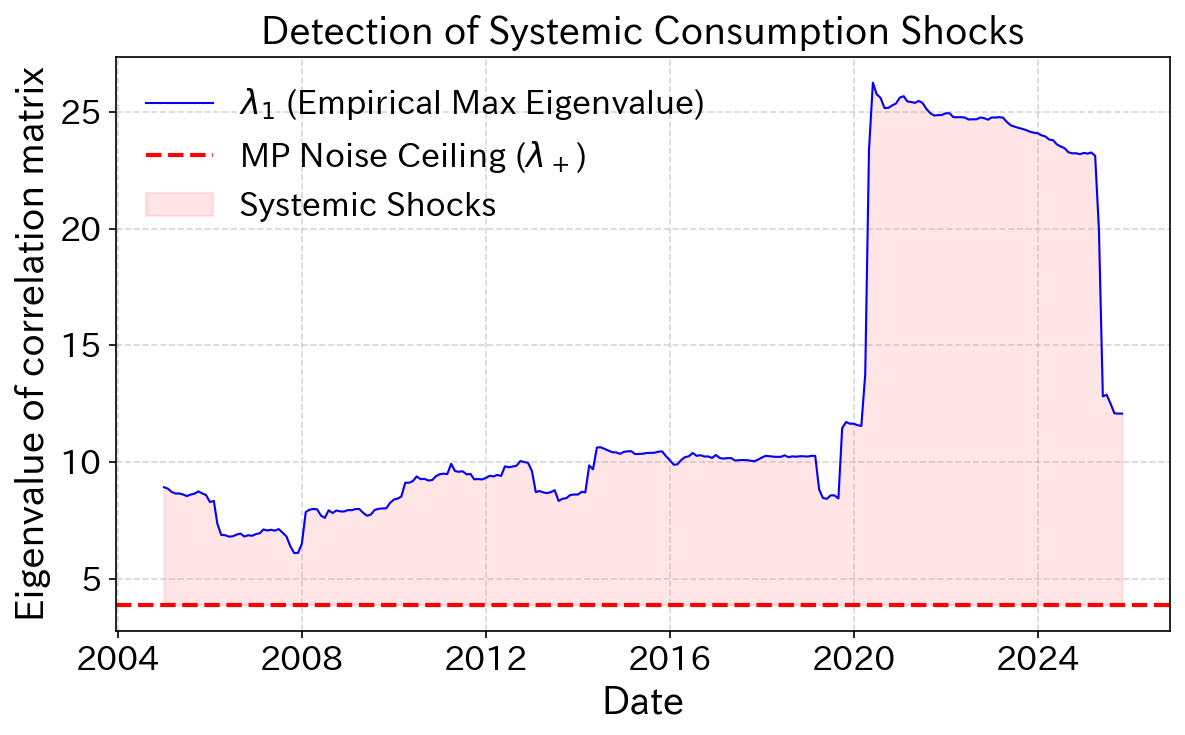

In [210]:
# --- Execution Pipeline ---

# STEP 1: Clean and Transpose raw consumption data
df_clean = prep_data_for_stl(c3, meta_col_count=3)

# STEP 2: Apply STL to get the Residuals (Deviations from trend/seasonality)
df_residuals = df_clean.apply(get_residuals, period=12)

# STEP 3: Apply Z-Score Normalization
df_res_norm = df_residuals.apply(zscore)

# STEP 4: Output as Markdown
# Using .to_markdown() converts the dataframe head into a formatted markdown table
markdown_output = df_res_norm.head().to_markdown()
print(markdown_output)
print(df_res_norm.shape)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Optional: just to make plots look nicer

# --- 1. CRITICAL FIX: Window size must be > N (144) ---
window_size = 60  # Results in Q = 150/144 = 1.04
N = df_res_norm.shape[1]  # No.of items
Q = window_size / N   # The aspect ratio (T/N)

# MP Theory Noise Ceiling (Calculated once outside the loop)
lambda_plus = (1 + np.sqrt(1/Q))**2  

# --- 2. Rolling Window Loop (Correct as written) ---
lambda_max_series = []
dates = []

for i in range(len(df_res_norm) - window_size):
    # Slice current window
    window = df_res_norm.iloc[i : i + window_size]
    
    # Calculate correlation matrix and extract eigenvalues
    # Note: .eigvalsh is computationally faster for symmetric matrices
    corr_mat = window.corr()
    evals = np.linalg.eigvalsh(corr_mat)
    
    # Append the largest eigenvalue (Systemic Market Factor)
    lambda_max_series.append(max(evals))
    # Tag the date to the END of the rolling window
    dates.append(df_res_norm.index[i + window_size])

# --- 3. Visualization ---
plt.figure(figsize=(8, 5), dpi=150)
ax = plt.subplot(1,1,1)

# Plot empirical max eigenvalue
ax.plot(dates, lambda_max_series, color='blue', linewidth=1, label=r'$\lambda_1$ (Empirical Max Eigenvalue)')

# Plot theoretical noise ceiling
ax.axhline(y=lambda_plus, color='red', linestyle='--', linewidth=2, label=r'MP Noise Ceiling ($\lambda_+$)')

# Shaded area for visual impact (highlighting systemic shocks)
ax.fill_between(dates, lambda_max_series, lambda_plus, 
                where=(np.array(lambda_max_series) > lambda_plus), 
                color='red', alpha=0.1, label='Systemic Shocks')

ax.set_title('Detection of Systemic Consumption Shocks', fontsize=18, fontweight='bold')
ax.set_ylabel('Eigenvalue of correlation matrix', fontsize=18)
ax.set_xlabel('Date', fontsize=18)

# ax.set_ylim(0,5)  
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=16, loc='best', frameon=False)

ax.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()

# -------from medium sum up to 1st category

In [268]:
# --- STEP 1: Flatten your nested hierarchy dictionary ---
# This converts the complex structure into a simple 'Item: Category' lookup
category_map = {}

for l1_id, l1_info in hierarchy.items():
    l1_name = l1_info['name']
    # Dig into the 'med' (Level 2)
    for l2_id, l2_info in l1_info.get('med', {}).items():
        l2_name = l2_info['name']
        # Dig into the 'small' (Level 3)
        category_map[l2_name] = l1_name
        # for l3_id, l3_name in l2_info.get('small', {}).items():
        #     # Map the Level 3 item name to its Level 2 parent name
        #     category_map[l3_name] = l2_name

# Convert to a Series for easier handling
category_series = pd.Series(category_map)
category_series

grains                                                                 food
seafood                                                                food
meat                                                                   food
milk eggs                                                              food
Vegetables/seaweed                                                     food
fruit                                                                  food
Oils and seasonings                                                    food
Confectionery                                                          food
cooked food                                                            food
beverage                                                               food
Alcoholic beverages                                                    food
Eating out                                                             food
rent and ground rent                                              residence
Equipment re

# After Covid

Item
meat                                      0.057865
Vegetables/seaweed                        0.055616
seafood                                   0.055454
Oils and seasonings                       0.055123
milk eggs                                 0.046923
grains                                    0.046862
Educational and entertainment services    0.045643
Housework consumables                     0.041890
traffic                                   0.041466
fruit                                     0.039609
dtype: float64


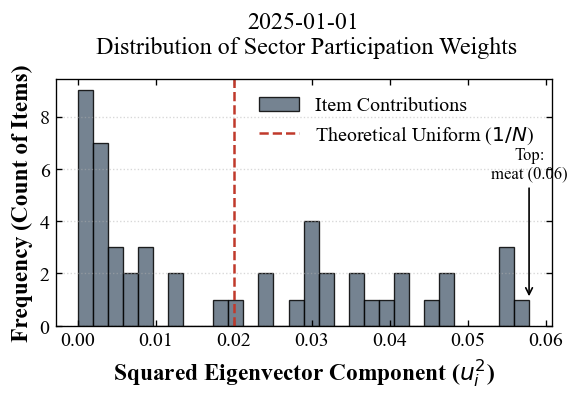


 --- Analysis for 2025-01-01 ---
After Civid-19 Shock
Max Eigenvalue (Systemic Strength): 16.12
IPR (0=Global, 1=Localized): 0.0372

Sector Contribution to this Shock:
food                             0.485176
clothing and footwear            0.169148
health care                      0.092307
educational entertainment        0.081379
Transportation/Communication     0.053657
Furniture/household supplies     0.053117
Other consumption expenditure    0.024802
Utilities/Water                  0.021347
residence                        0.012388
education                        0.006679
dtype: float64


In [269]:
# --- Execution Pipeline ---

# STEP 1: Clean and Transpose raw consumption data
df_clean = prep_data_for_stl(c2, meta_col_count=3)

# STEP 2: Apply STL to get the Residuals (Deviations from trend/seasonality)
df_residuals = df_clean.apply(get_residuals, period=12)

# STEP 3: Apply Z-Score Normalization
df_res_norm = df_residuals.apply(zscore)

import matplotlib.ticker as ticker
import numpy as np

def analyze_eigenvector_contribution(df_norm, target_date, category_lookup, window_size=60):
    """
    Performs Eigendecomposition on a specific window and maps results to categories.
    """
    # 1. Slice the data for the window ending at target_date
    idx = df_norm.index.get_loc(target_date)
    window_data = df_norm.iloc[idx - window_size : idx]
    
    # 2. Calculate Correlation and Eigendecomposition
    corr_mat = window_data.corr()
    # print(corr_mat)
    evals, evecs = np.linalg.eigh(corr_mat)
    
    # 3. Focus on the largest Eigenvalue (Lambda_1 is the last one in .eigh)
    lambda_1 = evals[-1]
    v_1 = evecs[:, -1]
    
    # 4. Math: Square the weights to get 'Energy Contribution' (u^2)
    # This represents how much variance of each item is explained by this mode.
    item_weights = pd.Series(v_1**2, index=corr_mat.columns)
    print(item_weights.sort_values(ascending=False).head(10))
    

    # --- 1. Setup Plot Style for Publication ---
    # Use serif fonts to match academic paper text (Times New Roman / Latin Modern)
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 12,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12
    })

    # Define the theoretical "Delocalized" value (1/N)
    # If N=50 items, 1/50 = 0.02. This is what we expect if NO sector dominates.
    N_items = len(item_weights)
    theoretical_mean = 1.0 / N_items

    # --- 2. Create Figure (Standard Column Width) ---
    # Width: 6 inches is standard for full width; 3.5 inches for single column
    fig, ax = plt.subplots(figsize=(5, 3.5), dpi=120)

    # --- 3. The Plot ---
    # Use a neutral, professional color (e.g., Slate Blue or Grey)
    # alpha=0.9 ensures grid lines don't show through too distractingly
    counts, bins, patches = ax.hist(
        item_weights, 
        bins=30, 
        color='#5D6D7E',  # Professional Slate Grey/Blue
        edgecolor='black', 
        linewidth=0.8,
        alpha=0.85,
        label='Item Contributions'
    )

    # --- 4. Scientific Annotations (The "Argument") ---

    # A. Theoretical Mean Line (The "Null Hypothesis")
    # This proves whether the shock is localized or global.
    ax.axvline(theoretical_mean, color='#C0392B', linestyle='--', linewidth=1.5, 
            label=r'Theoretical Uniform ($1/N$)')

    # B. Outlier Highlight (Optional but recommended)
    # Identify the item with the max contribution
    max_val = item_weights.max()
    max_item_name = item_weights.idxmax() # Gets the name like "Rice"
    ax.annotate(f'Top:\n{max_item_name} ({max_val:.2f})', 
                xy=(max_val, 1), # Point to the bar on x-axis (y is approximate)
                xytext=(max_val, ax.get_ylim()[1]*0.6), # Text position
                arrowprops=dict(facecolor='black', arrowstyle='->'),
                fontsize=10, ha='center')

    # --- 5. Polish Axes and Labels ---
    # Use LaTeX formatting for math symbols if possible
    ax.set_xlabel(r'Squared Eigenvector Component ($u_i^2$)', fontweight='bold')
    ax.set_ylabel('Frequency (Count of Items)', fontweight='bold')
    ax.set_title(f'{target_dt.date()}\n Distribution of Sector Participation Weights', pad=15)

    # Formatting Ticks (Inward ticks look more "scientific")
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(axis='y', linestyle=':', alpha=0.5) # Minimalist grid

    # Legend with no frame (cleaner)
    ax.legend(frameon=False, loc='upper right')

    # Tight layout handles padding automatically
    plt.tight_layout()

    plt.show()



    # --- . Group by Category to see Sector Contributions ---
    # 5. Group by Category
    # Filter map to ensure we only include items that exist in our current window
    current_map = category_lookup[category_lookup.index.isin(item_weights.index)]
    sector_contribution = item_weights.groupby(current_map).sum().sort_values(ascending=False)
    
    # 6. Calculate IPR for Localization check
    ipr = np.sum(v_1**4)
    
    return lambda_1, ipr, sector_contribution

# --- Execution ---
# Let's check the huge shock from 2020 seen in your plot
target_dt = pd.to_datetime('2025-01-01') 
l1, ipr_val, sectors = analyze_eigenvector_contribution(df_res_norm, target_dt, category_series)


print(f"\n --- Analysis for {target_dt.date()} ---")
print('After Civid-19 Shock')
print(f"Max Eigenvalue (Systemic Strength): {l1:.2f}")
print(f"IPR (0=Global, 1=Localized): {ipr_val:.4f}")
print("\nSector Contribution to this Shock:")
print(sectors.head(10)) # Top 10 categories

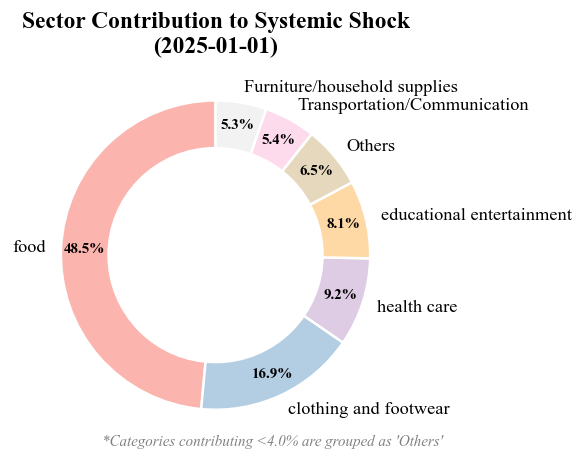

In [270]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_scientific_pie(sector_series, title_date, threshold=0.03):
    """
    Plots a pie chart where small categories are grouped into 'Others'.
    
    Parameters:
    - sector_series: The pandas Series of sector contributions (sum of u^2)
    - title_date: The date string for the title
    - threshold: Categories below this % (e.g., 0.03 = 3%) are grouped
    """
    
    # 1. Group small slices into 'Others'
    mask = sector_series >= threshold
    large_sectors = sector_series[mask]
    small_sectors = sector_series[~mask]
    
    if not small_sectors.empty:
        large_sectors['Others'] = small_sectors.sum()
    
    # 2. Prepare Data for Plotting
    # Sort so the biggest slice starts at 12 o'clock
    plot_data = large_sectors.sort_values(ascending=False)
    
    # 3. Setup Figure (High DPI for paper)
    fig, ax = plt.subplots(figsize=(5, 4), dpi=120)
    
    # 4. Color Palette (Professional/Academic)
    # Using a spectral or coolwarm map ensures distinct but not cartoonish colors
    colors = plt.get_cmap('Pastel1')(np.linspace(0, 1, len(plot_data)))
    
    # 5. Plot
    wedges, texts, autotexts = ax.pie(
        plot_data, 
        labels=plot_data.index,
        autopct='%1.1f%%',   # Show percentages like "51.3%"
        startangle=90,       # Start at top
        colors=colors,
        pctdistance=0.85,    # Move % inside
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5} # White lines between slices
    )
    
    # 6. Style the Text (Make it readable)
    for text in texts:
        text.set_fontsize(11)
        text.set_fontfamily('serif')
    for autotext in autotexts:
        autotext.set_fontsize(9)
        autotext.set_fontweight('bold')
        autotext.set_color('black')
        
    # Add a donut hole (Optional: Modern scientific style)
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)
    
    # 7. Titles and Labels
    plt.title(f"Sector Contribution to Systemic Shock\n({title_date})", 
              fontsize=14, fontfamily='serif', fontweight='bold')
    
    # Add a footnote about the threshold
    plt.figtext(0.5, 0.05, f"*Categories contributing <{threshold*100}% are grouped as 'Others'", 
                ha="center", fontsize=9, style='italic', color='gray')
    
    plt.tight_layout()
    plt.show()

# --- Execution Example ---
# Assuming 'sector_contribution' is the variable from your previous step
# And 'target_dt' is the date you analyzed (e.g., '2005-01-01')

plot_scientific_pie(sectors, "2025-01-01", threshold=0.04)

# -----Before Covid

Item
Oils and seasonings                      0.093112
milk eggs                                0.078025
meat                                     0.077378
seafood                                  0.072093
Housework consumables                    0.062737
cooked food                              0.060292
Confectionery                            0.053771
grains                                   0.051250
Vegetables/seaweed                       0.046471
Educational and recreational supplies    0.035618
dtype: float64


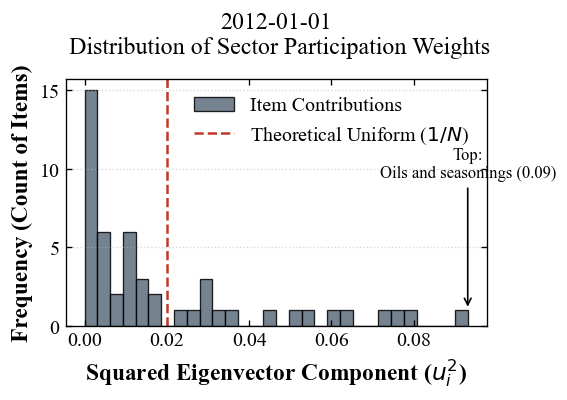


 --- Analysis for 2012-01-01 ---
Riman shock + Earthquake
Max Eigenvalue (Systemic Strength): 7.46
IPR (0=Global, 1=Localized): 0.0495

Sector Contribution to this Shock:
food                             0.612110
educational entertainment        0.074304
Furniture/household supplies     0.073113
health care                      0.049322
Transportation/Communication     0.044463
residence                        0.037344
Other consumption expenditure    0.034825
clothing and footwear            0.034312
Utilities/Water                  0.026509
education                        0.013698
dtype: float64


In [271]:
# --- Execution Pipeline ---

# STEP 1: Clean and Transpose raw consumption data
df_clean = prep_data_for_stl(c2, meta_col_count=3)

# STEP 2: Apply STL to get the Residuals (Deviations from trend/seasonality)
df_residuals = df_clean.apply(get_residuals, period=12)

# STEP 3: Apply Z-Score Normalization
df_res_norm = df_residuals.apply(zscore)

import matplotlib.ticker as ticker
import numpy as np

def analyze_eigenvector_contribution(df_norm, target_date, category_lookup, window_size=60):
    """
    Performs Eigendecomposition on a specific window and maps results to categories.
    """
    # 1. Slice the data for the window ending at target_date
    idx = df_norm.index.get_loc(target_date)
    window_data = df_norm.iloc[idx - window_size : idx]
    
    # 2. Calculate Correlation and Eigendecomposition
    corr_mat = window_data.corr()
    # print(corr_mat)
    evals, evecs = np.linalg.eigh(corr_mat)
    
    # 3. Focus on the largest Eigenvalue (Lambda_1 is the last one in .eigh)
    lambda_1 = evals[-1]
    v_1 = evecs[:, -1]
    
    # 4. Math: Square the weights to get 'Energy Contribution' (u^2)
    # This represents how much variance of each item is explained by this mode.
    item_weights = pd.Series(v_1**2, index=corr_mat.columns)
    print(item_weights.sort_values(ascending=False).head(10))
    

    # --- 1. Setup Plot Style for Publication ---
    # Use serif fonts to match academic paper text (Times New Roman / Latin Modern)
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 12,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12
    })

    # Define the theoretical "Delocalized" value (1/N)
    # If N=50 items, 1/50 = 0.02. This is what we expect if NO sector dominates.
    N_items = len(item_weights)
    theoretical_mean = 1.0 / N_items

    # --- 2. Create Figure (Standard Column Width) ---
    # Width: 6 inches is standard for full width; 3.5 inches for single column
    fig, ax = plt.subplots(figsize=(5, 3.5), dpi=120)

    # --- 3. The Plot ---
    # Use a neutral, professional color (e.g., Slate Blue or Grey)
    # alpha=0.9 ensures grid lines don't show through too distractingly
    counts, bins, patches = ax.hist(
        item_weights, 
        bins=30, 
        color='#5D6D7E',  # Professional Slate Grey/Blue
        edgecolor='black', 
        linewidth=0.8,
        alpha=0.85,
        label='Item Contributions'
    )

    # --- 4. Scientific Annotations (The "Argument") ---

    # A. Theoretical Mean Line (The "Null Hypothesis")
    # This proves whether the shock is localized or global.
    ax.axvline(theoretical_mean, color='#C0392B', linestyle='--', linewidth=1.5, 
            label=r'Theoretical Uniform ($1/N$)')

    # B. Outlier Highlight (Optional but recommended)
    # Identify the item with the max contribution
    max_val = item_weights.max()
    max_item_name = item_weights.idxmax() # Gets the name like "Rice"
    ax.annotate(f'Top:\n{max_item_name} ({max_val:.2f})', 
                xy=(max_val, 1), # Point to the bar on x-axis (y is approximate)
                xytext=(max_val, ax.get_ylim()[1]*0.6), # Text position
                arrowprops=dict(facecolor='black', arrowstyle='->'),
                fontsize=10, ha='center')

    # --- 5. Polish Axes and Labels ---
    # Use LaTeX formatting for math symbols if possible
    ax.set_xlabel(r'Squared Eigenvector Component ($u_i^2$)', fontweight='bold')
    ax.set_ylabel('Frequency (Count of Items)', fontweight='bold')
    ax.set_title(f'{target_dt.date()}\n Distribution of Sector Participation Weights', pad=15)

    # Formatting Ticks (Inward ticks look more "scientific")
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(axis='y', linestyle=':', alpha=0.5) # Minimalist grid

    # Legend with no frame (cleaner)
    ax.legend(frameon=False, loc='upper right')

    # Tight layout handles padding automatically
    plt.tight_layout()

    plt.show()



    # --- . Group by Category to see Sector Contributions ---
    # 5. Group by Category
    # Filter map to ensure we only include items that exist in our current window
    current_map = category_lookup[category_lookup.index.isin(item_weights.index)]
    sector_contribution = item_weights.groupby(current_map).sum().sort_values(ascending=False)
    
    # 6. Calculate IPR for Localization check
    ipr = np.sum(v_1**4)
    
    return lambda_1, ipr, sector_contribution

# --- Execution ---
# Let's check the huge shock from 2020 seen in your plot
target_dt = pd.to_datetime('2012-01-01') 
l1, ipr_val, sectors = analyze_eigenvector_contribution(df_res_norm, target_dt, category_series)


print(f"\n --- Analysis for {target_dt.date()} ---")
print('Riman shock + Earthquake')
print(f"Max Eigenvalue (Systemic Strength): {l1:.2f}")
print(f"IPR (0=Global, 1=Localized): {ipr_val:.4f}")
print("\nSector Contribution to this Shock:")
print(sectors.head(10)) # Top 10 categories

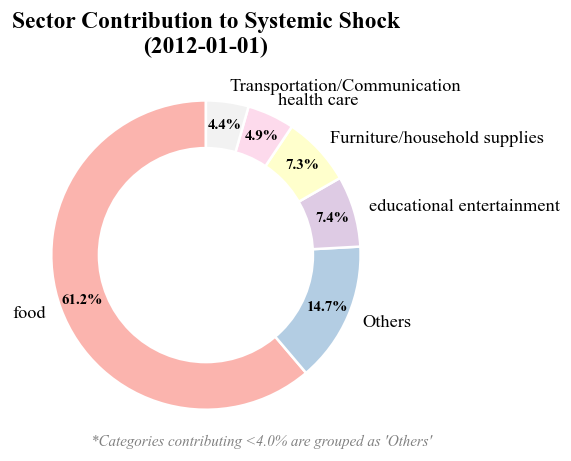

In [272]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_scientific_pie(sector_series, title_date, threshold=0.03):
    """
    Plots a pie chart where small categories are grouped into 'Others'.
    
    Parameters:
    - sector_series: The pandas Series of sector contributions (sum of u^2)
    - title_date: The date string for the title
    - threshold: Categories below this % (e.g., 0.03 = 3%) are grouped
    """
    
    # 1. Group small slices into 'Others'
    mask = sector_series >= threshold
    large_sectors = sector_series[mask]
    small_sectors = sector_series[~mask]
    
    if not small_sectors.empty:
        large_sectors['Others'] = small_sectors.sum()
    
    # 2. Prepare Data for Plotting
    # Sort so the biggest slice starts at 12 o'clock
    plot_data = large_sectors.sort_values(ascending=False)
    
    # 3. Setup Figure (High DPI for paper)
    fig, ax = plt.subplots(figsize=(5, 4), dpi=120)
    
    # 4. Color Palette (Professional/Academic)
    # Using a spectral or coolwarm map ensures distinct but not cartoonish colors
    colors = plt.get_cmap('Pastel1')(np.linspace(0, 1, len(plot_data)))
    
    # 5. Plot
    wedges, texts, autotexts = ax.pie(
        plot_data, 
        labels=plot_data.index,
        autopct='%1.1f%%',   # Show percentages like "51.3%"
        startangle=90,       # Start at top
        colors=colors,
        pctdistance=0.85,    # Move % inside
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5} # White lines between slices
    )
    
    # 6. Style the Text (Make it readable)
    for text in texts:
        text.set_fontsize(11)
        text.set_fontfamily('serif')
    for autotext in autotexts:
        autotext.set_fontsize(9)
        autotext.set_fontweight('bold')
        autotext.set_color('black')
        
    # Add a donut hole (Optional: Modern scientific style)
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)
    
    # 7. Titles and Labels
    plt.title(f"Sector Contribution to Systemic Shock\n({title_date})", 
              fontsize=14, fontfamily='serif', fontweight='bold')
    
    # Add a footnote about the threshold
    plt.figtext(0.5, 0.05, f"*Categories contributing <{threshold*100}% are grouped as 'Others'", 
                ha="center", fontsize=9, style='italic', color='gray')
    
    plt.tight_layout()
    plt.show()

# --- Execution Example ---
# Assuming 'sector_contribution' is the variable from your previous step
# And 'target_dt' is the date you analyzed (e.g., '2005-01-01')

plot_scientific_pie(sectors, "2012-01-01", threshold=0.04)

In [273]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_sector_contribution_timeseries(df_norm, category_lookup, window_size=60):
    """
    Loops through the data to calculate Sector Contributions to Lambda_1 over time.
    
    Returns:
        pd.DataFrame: Index is Date, Columns are Categories (e.g., 'Food', 'Transport')
                      Values are the sum of squared eigenvector weights for that sector.
    """
    results = []
    dates = []
    
    # Pre-calculate column intersection to speed up loop
    valid_cols = df_norm.columns
    # Filter lookup to match columns
    current_lookup = category_lookup[category_lookup.index.isin(valid_cols)]

    print(f"Starting extraction... Total windows: {len(df_norm) - window_size}")

    for i in range(len(df_norm) - window_size):
        # 1. Slice Window
        window_data = df_norm.iloc[i : i + window_size]
        current_date = df_norm.index[i + window_size]
        
        # 2. Correlation & Eigenvectors
        # We assume df_norm is already standardized
        corr_mat = window_data.corr()
        evals, evecs = np.linalg.eigh(corr_mat)
        
        # 3. Get Largest Mode (Lambda_1)
        # v_1 is the eigenvector corresponding to the largest eigenvalue
        v_1 = evecs[:, -1]
        
        # 4. Calculate Sector Power (Sum of Squared Weights)
        item_weights = pd.Series(v_1**2, index=window_data.columns)
        
        # Group by Category and Sum
        sector_power = item_weights.groupby(current_lookup).sum()
        
        results.append(sector_power)
        dates.append(current_date)
        
    # Combine into a DataFrame
    df_sector_ts = pd.DataFrame(results, index=dates)
    return df_sector_ts

# --- EXECUTION ---

# Run the extraction (This might take 10-20 seconds)
df_sector_contributions = get_sector_contribution_timeseries(
    df_res_norm, 
    category_series, # Your category mapping
    window_size=60   # Keep consistent with your analysis
)

# Check the first few rows
print(df_sector_contributions.head())

Starting extraction... Total windows: 251
            Furniture/household supplies  Other consumption expenditure  \
2005-01-01                      0.097544                       0.070797   
2005-02-01                      0.096582                       0.070196   
2005-03-01                      0.096964                       0.070616   
2005-04-01                      0.099606                       0.071040   
2005-05-01                      0.098905                       0.070896   

            Transportation/Communication  Utilities/Water  \
2005-01-01                      0.069210         0.025503   
2005-02-01                      0.069229         0.025537   
2005-03-01                      0.069837         0.025865   
2005-04-01                      0.070168         0.022607   
2005-05-01                      0.073357         0.023190   

            clothing and footwear  education  educational entertainment  \
2005-01-01               0.066661   0.019488                   0.

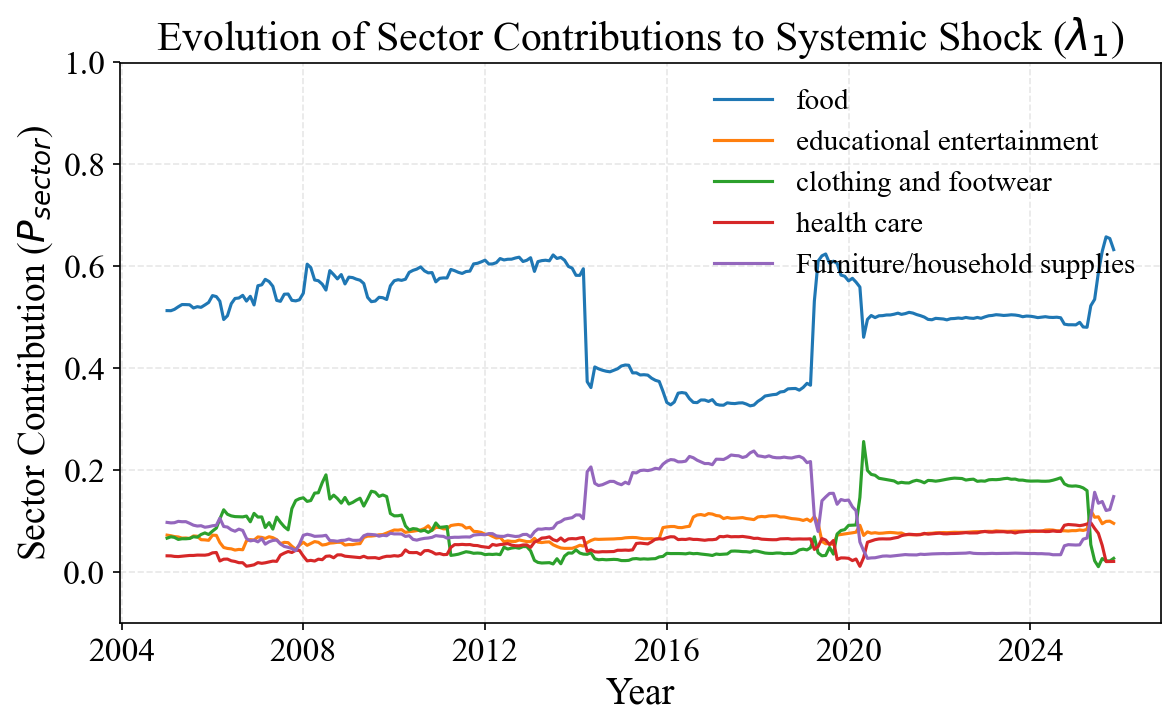

In [ ]:
# --- PLOTTING ---

# Select specific sectors you are interested in
target_sectors = ['food', 'educational entertainment', 'clothing and footwear', 'health care', 'Furniture/household supplies'] 
# (Make sure these names match exactly what is in your category_series)

plt.figure(figsize=(8, 5), dpi=150)
ax = plt.subplot(1,1,1)

# Plot each selected sector
for sector in target_sectors:
    if sector in df_sector_contributions.columns:
        ax.plot(df_sector_contributions.index, 
                df_sector_contributions[sector], 
                label=sector, linewidth=1.5)

# Add reference line for "Dominance"
# If a sector crosses 0.3 or 0.4, it is driving the market.
# ax.axhline(y=0.2, color='gray', linestyle=':', alpha=0.5, label='Significance Threshold')

# Formatting
ax.set_title('Evolution of Sector Contributions to Systemic Shock ($\lambda_1$)', fontsize=20, fontfamily='serif')
ax.set_ylabel('Sector Contribution ($P_{sector}$)', fontsize=18, fontfamily='serif')
ax.set_xlabel('Year', fontsize=18, fontfamily='serif')
ax.legend(frameon=False, loc='best', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=16)

ax.set_ylim(-0.1, 1)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### -----from small canegory to sum up

In [260]:
# --- STEP 1: Flatten your nested hierarchy dictionary ---
# This converts the complex structure into a simple 'Item: Category' lookup
category_map = {}

for l1_id, l1_info in hierarchy.items():
    l1_name = l1_info['name']
    # Dig into the 'med' (Level 2)
    for l2_id, l2_info in l1_info.get('med', {}).items():
        l2_name = l2_info['name']
        # Dig into the 'small' (Level 3)
        # category_map[l2_name] = l1_name
        for l3_id, l3_name in l2_info.get('small', {}).items():
        #     # Map the Level 3 item name to its Level 2 parent name
            category_map[l3_name] = l1_name

# Convert to a Series for easier handling
category_series = pd.Series(category_map)
category_series

rice                                                                        food
bread                                                                       food
noodles                                                                     food
other grains                                                                food
fresh seafood                                                               food
salted and dried seafood                                                    food
Fish paste products                                                         food
Other processed seafood products                                            food
fresh meat                                                                  food
processed meat                                                              food
milk                                                                        food
dairy products                                                              food
egg                         

Item
seasoning                           0.083238
bread                               0.059689
Processed soybean products          0.056147
noodles                             0.054164
fresh meat                          0.051697
fresh seafood                       0.048848
Other processed seafood products    0.047985
Fish paste products                 0.044320
Dry food/seaweed                    0.043830
egg                                 0.042433
dtype: float64


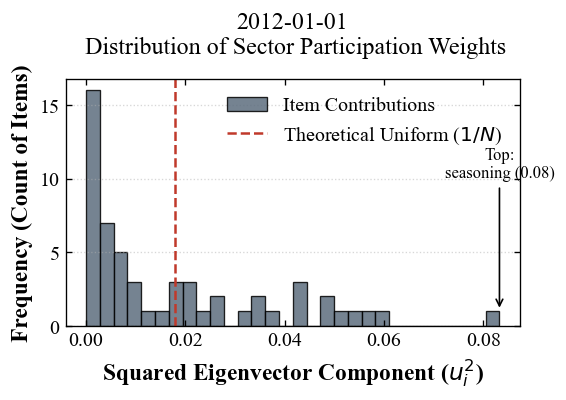


 --- Analysis for 2012-01-01 ---
Riman shock + Earthquake
Max Eigenvalue (Systemic Strength): 9.32
IPR (0=Global, 1=Localized): 0.0398

Sector Contribution to this Shock:
food                             0.875156
Other consumption expenditure    0.029806
Transportation/Communication     0.029623
clothing and footwear            0.021298
educational entertainment        0.018856
residence                        0.016395
Furniture/household supplies     0.008865
dtype: float64


In [262]:
# --- Execution Pipeline ---

# STEP 1: Clean and Transpose raw consumption data
df_clean = prep_data_for_stl(c3, meta_col_count=3)

# STEP 2: Apply STL to get the Residuals (Deviations from trend/seasonality)
df_residuals = df_clean.apply(get_residuals, period=12)

# STEP 3: Apply Z-Score Normalization
df_res_norm = df_residuals.apply(zscore)

import matplotlib.ticker as ticker
import numpy as np

def analyze_eigenvector_contribution(df_norm, target_date, category_lookup, window_size=60):
    """
    Performs Eigendecomposition on a specific window and maps results to categories.
    """
    # 1. Slice the data for the window ending at target_date
    idx = df_norm.index.get_loc(target_date)
    window_data = df_norm.iloc[idx - window_size : idx]
    
    # 2. Calculate Correlation and Eigendecomposition
    corr_mat = window_data.corr()
    # print(corr_mat)
    evals, evecs = np.linalg.eigh(corr_mat)
    
    # 3. Focus on the largest Eigenvalue (Lambda_1 is the last one in .eigh)
    lambda_1 = evals[-1]
    v_1 = evecs[:, -1]
    
    # 4. Math: Square the weights to get 'Energy Contribution' (u^2)
    # This represents how much variance of each item is explained by this mode.
    item_weights = pd.Series(v_1**2, index=corr_mat.columns)
    print(item_weights.sort_values(ascending=False).head(10))
    

    # --- 1. Setup Plot Style for Publication ---
    # Use serif fonts to match academic paper text (Times New Roman / Latin Modern)
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 12,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12
    })

    # Define the theoretical "Delocalized" value (1/N)
    # If N=50 items, 1/50 = 0.02. This is what we expect if NO sector dominates.
    N_items = len(item_weights)
    theoretical_mean = 1.0 / N_items

    # --- 2. Create Figure (Standard Column Width) ---
    # Width: 6 inches is standard for full width; 3.5 inches for single column
    fig, ax = plt.subplots(figsize=(5, 3.5), dpi=120)

    # --- 3. The Plot ---
    # Use a neutral, professional color (e.g., Slate Blue or Grey)
    # alpha=0.9 ensures grid lines don't show through too distractingly
    counts, bins, patches = ax.hist(
        item_weights, 
        bins=30, 
        color='#5D6D7E',  # Professional Slate Grey/Blue
        edgecolor='black', 
        linewidth=0.8,
        alpha=0.85,
        label='Item Contributions'
    )

    # --- 4. Scientific Annotations (The "Argument") ---

    # A. Theoretical Mean Line (The "Null Hypothesis")
    # This proves whether the shock is localized or global.
    ax.axvline(theoretical_mean, color='#C0392B', linestyle='--', linewidth=1.5, 
            label=r'Theoretical Uniform ($1/N$)')

    # B. Outlier Highlight (Optional but recommended)
    # Identify the item with the max contribution
    max_val = item_weights.max()
    max_item_name = item_weights.idxmax() # Gets the name like "Rice"
    ax.annotate(f'Top:\n{max_item_name} ({max_val:.2f})', 
                xy=(max_val, 1), # Point to the bar on x-axis (y is approximate)
                xytext=(max_val, ax.get_ylim()[1]*0.6), # Text position
                arrowprops=dict(facecolor='black', arrowstyle='->'),
                fontsize=10, ha='center')

    # --- 5. Polish Axes and Labels ---
    # Use LaTeX formatting for math symbols if possible
    ax.set_xlabel(r'Squared Eigenvector Component ($u_i^2$)', fontweight='bold')
    ax.set_ylabel('Frequency (Count of Items)', fontweight='bold')
    ax.set_title(f'{target_dt.date()}\n Distribution of Sector Participation Weights', pad=15)

    # Formatting Ticks (Inward ticks look more "scientific")
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(axis='y', linestyle=':', alpha=0.5) # Minimalist grid

    # Legend with no frame (cleaner)
    ax.legend(frameon=False, loc='upper right')

    # Tight layout handles padding automatically
    plt.tight_layout()

    plt.show()



    # --- . Group by Category to see Sector Contributions ---
    # 5. Group by Category
    # Filter map to ensure we only include items that exist in our current window
    current_map = category_lookup[category_lookup.index.isin(item_weights.index)]
    sector_contribution = item_weights.groupby(current_map).sum().sort_values(ascending=False)
    
    # 6. Calculate IPR for Localization check
    ipr = np.sum(v_1**4)
    
    return lambda_1, ipr, sector_contribution

# --- Execution ---
# Let's check the huge shock from 2020 seen in your plot
target_dt = pd.to_datetime('2012-01-01') 
l1, ipr_val, sectors = analyze_eigenvector_contribution(df_res_norm, target_dt, category_series)


print(f"\n --- Analysis for {target_dt.date()} ---")
print('Riman shock + Earthquake')
print(f"Max Eigenvalue (Systemic Strength): {l1:.2f}")
print(f"IPR (0=Global, 1=Localized): {ipr_val:.4f}")
print("\nSector Contribution to this Shock:")
print(sectors.head(10)) # Top 10 categories

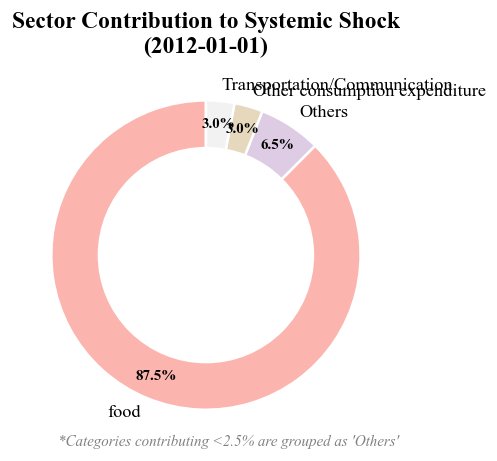

In [265]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_scientific_pie(sector_series, title_date, threshold=0.03):
    """
    Plots a pie chart where small categories are grouped into 'Others'.
    
    Parameters:
    - sector_series: The pandas Series of sector contributions (sum of u^2)
    - title_date: The date string for the title
    - threshold: Categories below this % (e.g., 0.03 = 3%) are grouped
    """
    
    # 1. Group small slices into 'Others'
    mask = sector_series >= threshold
    large_sectors = sector_series[mask]
    small_sectors = sector_series[~mask]
    
    if not small_sectors.empty:
        large_sectors['Others'] = small_sectors.sum()
    
    # 2. Prepare Data for Plotting
    # Sort so the biggest slice starts at 12 o'clock
    plot_data = large_sectors.sort_values(ascending=False)
    
    # 3. Setup Figure (High DPI for paper)
    fig, ax = plt.subplots(figsize=(5, 4), dpi=120)
    
    # 4. Color Palette (Professional/Academic)
    # Using a spectral or coolwarm map ensures distinct but not cartoonish colors
    colors = plt.get_cmap('Pastel1')(np.linspace(0, 1, len(plot_data)))
    
    # 5. Plot
    wedges, texts, autotexts = ax.pie(
        plot_data, 
        labels=plot_data.index,
        autopct='%1.1f%%',   # Show percentages like "51.3%"
        startangle=90,       # Start at top
        colors=colors,
        pctdistance=0.85,    # Move % inside
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5} # White lines between slices
    )
    
    # 6. Style the Text (Make it readable)
    for text in texts:
        text.set_fontsize(11)
        text.set_fontfamily('serif')
    for autotext in autotexts:
        autotext.set_fontsize(9)
        autotext.set_fontweight('bold')
        autotext.set_color('black')
        
    # Add a donut hole (Optional: Modern scientific style)
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)
    
    # 7. Titles and Labels
    plt.title(f"Sector Contribution to Systemic Shock\n({title_date})", 
              fontsize=14, fontfamily='serif', fontweight='bold')
    
    # Add a footnote about the threshold
    plt.figtext(0.5, 0.05, f"*Categories contributing <{threshold*100}% are grouped as 'Others'", 
                ha="center", fontsize=9, style='italic', color='gray')
    
    plt.tight_layout()
    plt.show()

# --- Execution Example ---
# Assuming 'sector_contribution' is the variable from your previous step
# And 'target_dt' is the date you analyzed (e.g., '2005-01-01')

plot_scientific_pie(sectors, "2012-01-01", threshold=0.025)

Item
fresh meat                                         0.039814
processed meat                                     0.039630
seasoning                                          0.038721
Processed soybean products                         0.037606
Other processed vegetables and seaweed products    0.036652
noodles                                            0.036072
fresh vegetables                                   0.035682
other grains                                       0.034748
salted and dried seafood                           0.033851
Fish paste products                                0.033053
dtype: float64


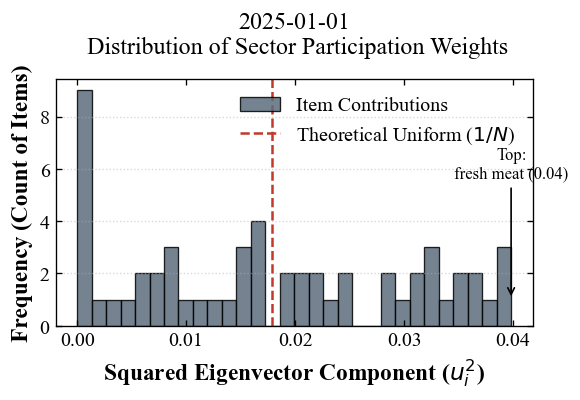


 --- Analysis for 2025-01-01 ---
Riman shock + Earthquake
Max Eigenvalue (Systemic Strength): 23.26
IPR (0=Global, 1=Localized): 0.0271

Sector Contribution to this Shock:
food                             0.762142
clothing and footwear            0.103086
educational entertainment        0.075127
Other consumption expenditure    0.050312
residence                        0.004862
Transportation/Communication     0.002590
Furniture/household supplies     0.001882
dtype: float64


In [266]:
# --- Execution Pipeline ---

# STEP 1: Clean and Transpose raw consumption data
df_clean = prep_data_for_stl(c3, meta_col_count=3)

# STEP 2: Apply STL to get the Residuals (Deviations from trend/seasonality)
df_residuals = df_clean.apply(get_residuals, period=12)

# STEP 3: Apply Z-Score Normalization
df_res_norm = df_residuals.apply(zscore)

import matplotlib.ticker as ticker
import numpy as np

def analyze_eigenvector_contribution(df_norm, target_date, category_lookup, window_size=60):
    """
    Performs Eigendecomposition on a specific window and maps results to categories.
    """
    # 1. Slice the data for the window ending at target_date
    idx = df_norm.index.get_loc(target_date)
    window_data = df_norm.iloc[idx - window_size : idx]
    
    # 2. Calculate Correlation and Eigendecomposition
    corr_mat = window_data.corr()
    # print(corr_mat)
    evals, evecs = np.linalg.eigh(corr_mat)
    
    # 3. Focus on the largest Eigenvalue (Lambda_1 is the last one in .eigh)
    lambda_1 = evals[-1]
    v_1 = evecs[:, -1]
    
    # 4. Math: Square the weights to get 'Energy Contribution' (u^2)
    # This represents how much variance of each item is explained by this mode.
    item_weights = pd.Series(v_1**2, index=corr_mat.columns)
    print(item_weights.sort_values(ascending=False).head(10))
    

    # --- 1. Setup Plot Style for Publication ---
    # Use serif fonts to match academic paper text (Times New Roman / Latin Modern)
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 12,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12
    })

    # Define the theoretical "Delocalized" value (1/N)
    # If N=50 items, 1/50 = 0.02. This is what we expect if NO sector dominates.
    N_items = len(item_weights)
    theoretical_mean = 1.0 / N_items

    # --- 2. Create Figure (Standard Column Width) ---
    # Width: 6 inches is standard for full width; 3.5 inches for single column
    fig, ax = plt.subplots(figsize=(5, 3.5), dpi=120)

    # --- 3. The Plot ---
    # Use a neutral, professional color (e.g., Slate Blue or Grey)
    # alpha=0.9 ensures grid lines don't show through too distractingly
    counts, bins, patches = ax.hist(
        item_weights, 
        bins=30, 
        color='#5D6D7E',  # Professional Slate Grey/Blue
        edgecolor='black', 
        linewidth=0.8,
        alpha=0.85,
        label='Item Contributions'
    )

    # --- 4. Scientific Annotations (The "Argument") ---

    # A. Theoretical Mean Line (The "Null Hypothesis")
    # This proves whether the shock is localized or global.
    ax.axvline(theoretical_mean, color='#C0392B', linestyle='--', linewidth=1.5, 
            label=r'Theoretical Uniform ($1/N$)')

    # B. Outlier Highlight (Optional but recommended)
    # Identify the item with the max contribution
    max_val = item_weights.max()
    max_item_name = item_weights.idxmax() # Gets the name like "Rice"
    ax.annotate(f'Top:\n{max_item_name} ({max_val:.2f})', 
                xy=(max_val, 1), # Point to the bar on x-axis (y is approximate)
                xytext=(max_val, ax.get_ylim()[1]*0.6), # Text position
                arrowprops=dict(facecolor='black', arrowstyle='->'),
                fontsize=10, ha='center')

    # --- 5. Polish Axes and Labels ---
    # Use LaTeX formatting for math symbols if possible
    ax.set_xlabel(r'Squared Eigenvector Component ($u_i^2$)', fontweight='bold')
    ax.set_ylabel('Frequency (Count of Items)', fontweight='bold')
    ax.set_title(f'{target_dt.date()}\n Distribution of Sector Participation Weights', pad=15)

    # Formatting Ticks (Inward ticks look more "scientific")
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(axis='y', linestyle=':', alpha=0.5) # Minimalist grid

    # Legend with no frame (cleaner)
    ax.legend(frameon=False, loc='upper right')

    # Tight layout handles padding automatically
    plt.tight_layout()

    plt.show()



    # --- . Group by Category to see Sector Contributions ---
    # 5. Group by Category
    # Filter map to ensure we only include items that exist in our current window
    current_map = category_lookup[category_lookup.index.isin(item_weights.index)]
    sector_contribution = item_weights.groupby(current_map).sum().sort_values(ascending=False)
    
    # 6. Calculate IPR for Localization check
    ipr = np.sum(v_1**4)
    
    return lambda_1, ipr, sector_contribution

# --- Execution ---
# Let's check the huge shock from 2020 seen in your plot
target_dt = pd.to_datetime('2025-01-01') 
l1, ipr_val, sectors = analyze_eigenvector_contribution(df_res_norm, target_dt, category_series)


print(f"\n --- Analysis for {target_dt.date()} ---")
print('Riman shock + Earthquake')
print(f"Max Eigenvalue (Systemic Strength): {l1:.2f}")
print(f"IPR (0=Global, 1=Localized): {ipr_val:.4f}")
print("\nSector Contribution to this Shock:")
print(sectors.head(10)) # Top 10 categories

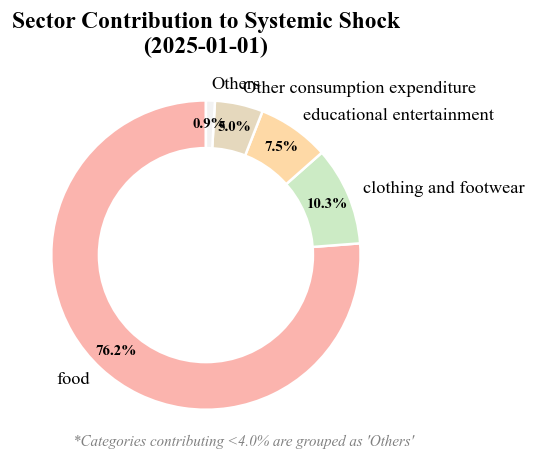

In [267]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_scientific_pie(sector_series, title_date, threshold=0.03):
    """
    Plots a pie chart where small categories are grouped into 'Others'.
    
    Parameters:
    - sector_series: The pandas Series of sector contributions (sum of u^2)
    - title_date: The date string for the title
    - threshold: Categories below this % (e.g., 0.03 = 3%) are grouped
    """
    
    # 1. Group small slices into 'Others'
    mask = sector_series >= threshold
    large_sectors = sector_series[mask]
    small_sectors = sector_series[~mask]
    
    if not small_sectors.empty:
        large_sectors['Others'] = small_sectors.sum()
    
    # 2. Prepare Data for Plotting
    # Sort so the biggest slice starts at 12 o'clock
    plot_data = large_sectors.sort_values(ascending=False)
    
    # 3. Setup Figure (High DPI for paper)
    fig, ax = plt.subplots(figsize=(5, 4), dpi=120)
    
    # 4. Color Palette (Professional/Academic)
    # Using a spectral or coolwarm map ensures distinct but not cartoonish colors
    colors = plt.get_cmap('Pastel1')(np.linspace(0, 1, len(plot_data)))
    
    # 5. Plot
    wedges, texts, autotexts = ax.pie(
        plot_data, 
        labels=plot_data.index,
        autopct='%1.1f%%',   # Show percentages like "51.3%"
        startangle=90,       # Start at top
        colors=colors,
        pctdistance=0.85,    # Move % inside
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5} # White lines between slices
    )
    
    # 6. Style the Text (Make it readable)
    for text in texts:
        text.set_fontsize(11)
        text.set_fontfamily('serif')
    for autotext in autotexts:
        autotext.set_fontsize(9)
        autotext.set_fontweight('bold')
        autotext.set_color('black')
        
    # Add a donut hole (Optional: Modern scientific style)
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)
    
    # 7. Titles and Labels
    plt.title(f"Sector Contribution to Systemic Shock\n({title_date})", 
              fontsize=14, fontfamily='serif', fontweight='bold')
    
    # Add a footnote about the threshold
    plt.figtext(0.5, 0.05, f"*Categories contributing <{threshold*100}% are grouped as 'Others'", 
                ha="center", fontsize=9, style='italic', color='gray')
    
    plt.tight_layout()
    plt.show()

# --- Execution Example ---
# Assuming 'sector_contribution' is the variable from your previous step
# And 'target_dt' is the date you analyzed (e.g., '2005-01-01')

plot_scientific_pie(sectors, "2025-01-01", threshold=0.04)

Since your correlation matrix $\mathbf{C}$ is symmetric (meaning $C_{ij} = C_{ji}$) and real-valued, linear algebra guarantees that it can be broken down into a specific sum of distinct "layers."Here is the step-by-step mathematical derivation of why $\mathbf{C} = \sum \lambda_k \mathbf{v}_k \mathbf{v}_k^T$ and how the mapping works.1. The Foundation: Eigenvalue EquationBy definition, an eigenvector $\mathbf{v}$ and eigenvalue $\lambda$ of a matrix $\mathbf{C}$ satisfy:$$\mathbf{C} \mathbf{v} = \lambda \mathbf{v}$$This means that when matrix $\mathbf{C}$ acts on vector $\mathbf{v}$, it only stretches it by a factor of $\lambda$; it does not rotate it.Since $\mathbf{C}$ is size $N \times N$, there are $N$ such eigenvectors ($\mathbf{v}_1, \dots, \mathbf{v}_N$) and $N$ eigenvalues ($\lambda_1, \dots, \lambda_N$).

## 2. Matrix Diagonalization (The "Why")We can stack all these equations together into single matrix notation.

Let $\mathbf{V}$ be a matrix where the columns are the eigenvectors:$$\mathbf{V} = [\mathbf{v}_1 | \mathbf{v}_2 | \dots | \mathbf{v}_N]$$

Let $\mathbf{\Lambda}$ be a diagonal matrix with eigenvalues on the diagonal:$$\mathbf{\Lambda} = \begin{bmatrix} \lambda_1 & 0 & \dots \\ 0 & \lambda_2 & \dots \\ \vdots & \vdots & \ddots \end{bmatrix}$$

The combined equation is:$$\mathbf{C} \mathbf{V} = \mathbf{V} \mathbf{\Lambda}$$To isolate $\mathbf{C}$, 
we multiply by $\mathbf{V}^{-1}$ on the right:$$\mathbf{C} = \mathbf{V} \mathbf{\Lambda} \mathbf{V}^{-1}$$The Magic of Symmetry:Because $\mathbf{C}$ is a symmetric matrix, its eigenvectors are orthogonal (perpendicular) to each other. Mathematically, this means $\mathbf{V}$ is an orthogonal matrix, so its inverse is simply its transpose:$$\mathbf{V}^{-1} = \mathbf{V}^T$$Substituting this back gives the Eigendecomposition Formula:$$\mathbf{C} = \mathbf{V} \mathbf{\Lambda} \mathbf{V}^T$$

## 3. Deriving the Summation (The "Outer Product")Now, let's look at what the multiplication $\mathbf{V} \mathbf{\Lambda} \mathbf{V}^T$ actually expands to.

Using the rules of matrix multiplication, this product can be written as a sum of outer products:
$$\mathbf{C} = \begin{bmatrix} \mathbf{v}_1 & \dots & \mathbf{v}_N \end{bmatrix}
\begin{bmatrix} \lambda_1 & & \\ & \ddots & \\ & & \lambda_N \end{bmatrix}$$

$$\begin{bmatrix} \mathbf{v}_1^T \\ \vdots \\ \mathbf{v}_N^T \end{bmatrix}$$

$$\mathbf{C} = \lambda_1 (\mathbf{v}_1 \mathbf{v}_1^T) + \lambda_2 (\mathbf{v}_2 \mathbf{v}_2^T) + \dots + \lambda_N (\mathbf{v}_N \mathbf{v}_N^T)$$

$$\mathbf{C} = \sum_{k=1}^{N} \lambda_k (\mathbf{v}_k \mathbf{v}_k^T)$$

## What does this mean physically?
$\mathbf{C}$ (The complex data structure) is actually just a sum of simple "rank-1" matrices.$\mathbf{v}_k \mathbf{v}_k^T$ is a pattern matrix (the "shape" of the shock).$\lambda_k$ is the scaling factor (the "strength" of the shock).

## 4. The Mapping: Why use $v_{k,i}^2$?

Now we answer your second question: How do we map this back to "Food" or "Transport"?We know that eigenvectors are normalized to length 1:$$||\mathbf{v}_k||^2 = \sum_{i=1}^{N} v_{k,i}^2 = 1$$

Here, $v_{k,i}$ is the component of the $k$-th eigenvector corresponding to Item $i$ (e.g., Bread).In Quantum Mechanics and RMT, $v_{k,i}^2$ represents the probability (or "energy contribution") of Item $i$ participating in Mode $k$.If $v_{1, \text{Bread}}^2 = 0.01$, Bread contributes $1\%$ to the systemic shock.If $v_{1, \text{Bread}}^2 = 0.50$, Bread contributes $50\%$ to the systemic shock.5. 